# 14. To implement multiclass classification using CNN on the CIFAR-10 dataset.

### Aim

To implement a Convolutional Neural Network (CNN) for multiclass image classification using the CIFAR-10 dataset.

## Introduction

Multiclass classification is a machine learning problem in which an input is assigned to one of more than two predefined classes.

The CIFAR-10 dataset contains images belonging to 10 different classes. In this practical, a CNN is used to learn visual features from the images and classify them into their respective categories.

CNNs are suitable for image classification because convolution layers automatically learn important features such as edges, textures, shapes, and patterns.

## CIFAR-10 Dataset

CIFAR-10 contains 60,000 RGB images belonging to 10 classes.

### Dataset Information

- Total Images: 60,000
- Training Images: 50,000
- Testing Images: 10,000
- Image Size: 32 × 32 pixels
- Image Channels: 3 (RGB)
- Number of Classes: 10

### Classes

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

## Multiclass Classification

In multiclass classification, the model predicts one class from multiple possible classes.

For CIFAR-10, the CNN output layer contains **10 neurons**, one for each class.

The **Softmax activation function** is used in the output layer to convert the model outputs into probabilities.

The class having the highest probability is selected as the predicted class.

## CNN Architecture

The CNN model consists of:

- Convolution Layer
- ReLU Activation
- Max Pooling Layer
- Convolution Layer
- ReLU Activation
- Max Pooling Layer
- Flatten Layer
- Dense Layer
- Output Layer with Softmax Activation

## Algorithm

1. Import the required libraries.
2. Load the CIFAR-10 dataset.
3. Define the class names.
4. Display sample images.
5. Normalize the image pixel values.
6. Build the CNN model.
7. Compile the model.
8. Train the CNN model.
9. Evaluate the model using test data.
10. Predict the classes of test images.
11. Compare predicted and actual classes.
12. Display the classification results.

In [1]:
#Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models

In [2]:
# Load CIFAR-10 dataset

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

Training Images : (50000, 32, 32, 3)
Testing Images  : (10000, 32, 32, 3)


In [3]:
#Define Class Names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

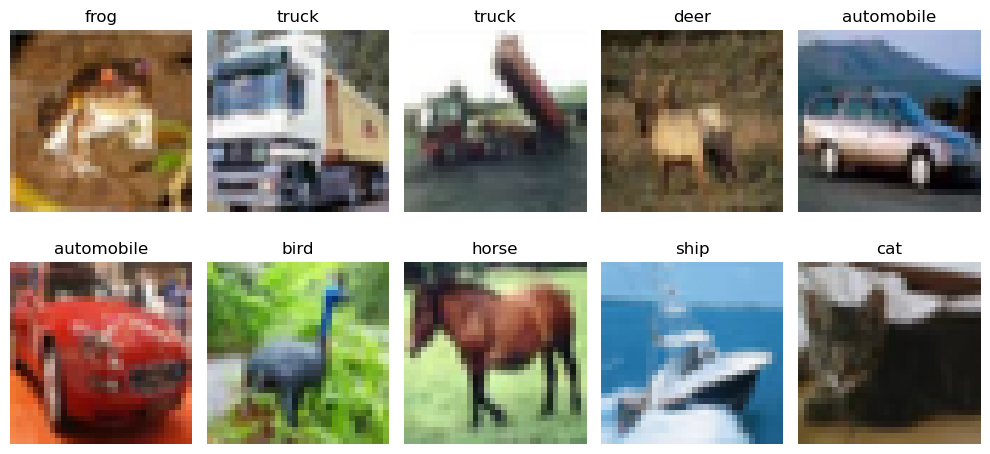

In [4]:
#Display Sample Images
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Data Preprocessing

The pixel values of CIFAR-10 images range from 0 to 255.

To make the training process more efficient, the pixel values are normalized to a range between 0 and 1 by dividing them by 255.

In [5]:
# Normalize pixel values

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Data normalization completed.")

Data normalization completed.


In [6]:
#Build CNN Model
model = models.Sequential([
    
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    
    layers.Flatten(),
    
    layers.Dense(
        128,
        activation='relu'
    ),
    
    layers.Dense(
        10,
        activation='softmax'
    )
])

C:\Users\Smit\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 188,810 (737.54 KB)

 Trainable params: 188,810 (737.54 KB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation

The CNN model is compiled using:

- **Adam Optimizer:** Updates the model weights during training.
- **Sparse Categorical Crossentropy:** Used as the loss function for multiclass classification.
- **Accuracy:** Used to measure the classification performance.

In [8]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
#Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.3406 - loss: 1.7834 - val_accuracy: 0.5233 - val_loss: 1.3188
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.5475 - loss: 1.2585 - val_accuracy: 0.5898 - val_loss: 1.1572
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.6128 - loss: 1.0938 - val_accuracy: 0.6302 - val_loss: 1.0522
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.6584 - loss: 0.9744 - val_accuracy: 0.6306 - val_loss: 1.0656
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.6888 - loss: 0.8927 - val_accuracy: 0.6630 - val_loss: 0.9384
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.7141 - loss: 0.8137 - val_accuracy: 0.6830 - val_loss: 0.9093
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.7436 - loss: 0.7381 - val_accuracy: 0.6971 - val_loss: 0.8798
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.7606 - loss: 0.6855 - 

In [10]:
#Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6880 - loss: 0.9326
Test Loss     : 0.9343622922897339
Test Accuracy : 0.6880000233650208


In [11]:
#Make Predictions
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted Class :", class_names[predicted_labels[0]])
print("Actual Class    :", class_names[y_test[0][0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Predicted Class : cat
Actual Class    : cat


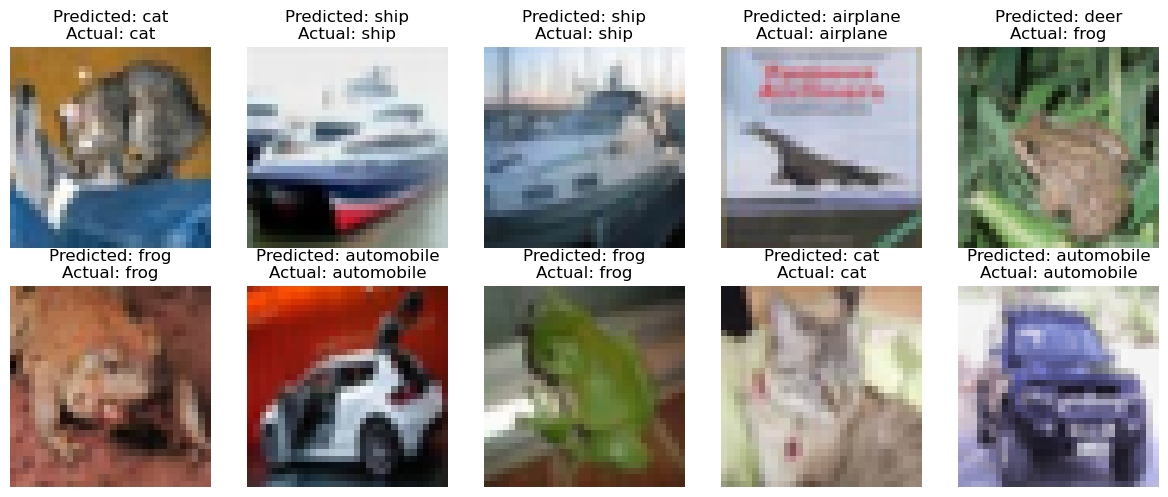

In [12]:
#Display Prediction Results
plt.figure(figsize=(12, 5))

for i in range(10):
    
    plt.subplot(2, 5, i + 1)
    
    plt.imshow(X_test[i])
    
    predicted = class_names[predicted_labels[i]]
    actual = class_names[y_test[i][0]]
    
    plt.title(f"Predicted: {predicted}\nActual: {actual}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Observation

- The CNN successfully learns visual features from CIFAR-10 images.
- The output layer contains 10 neurons corresponding to the 10 CIFAR-10 classes.
- Softmax assigns a probability to each class.
- The class with the highest probability is selected as the prediction.
- The CNN can classify images into multiple categories using the learned features.

## Result

A Convolutional Neural Network (CNN) was successfully implemented for multiclass classification using the CIFAR-10 dataset. The model learned visual features from the training images and classified images into 10 different categories using a Softmax output layer.